In [39]:
!pip install pandas matplotlib numpy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [40]:
import pandas as pd

df = pd.read_csv("penguins.csv")
df 

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214,4925,FEMALE
329,Gentoo,Biscoe,46.8,14.3,215,4850,FEMALE
330,Gentoo,Biscoe,50.4,15.7,222,5750,MALE
331,Gentoo,Biscoe,45.2,14.8,212,5200,FEMALE


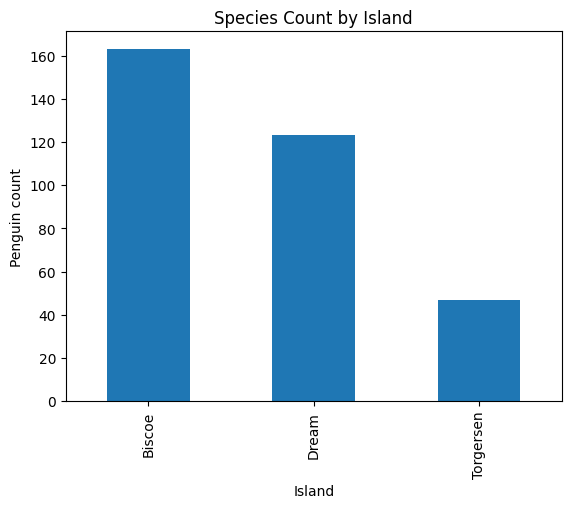

In [70]:
import matplotlib.pyplot as plt

island_count =df.groupby("island")["species"].count()
island_count.plot(kind="bar")

plt.title("Species Count by Island")
plt.xlabel("Island")
plt.ylabel("Penguin count")

plt.show()



Column chart — Species count by island

Biscoe has the highest number of penguin records, Dream is next, and Torgersen has the fewest.
Differences may reflect habitat suitability or sampling effort

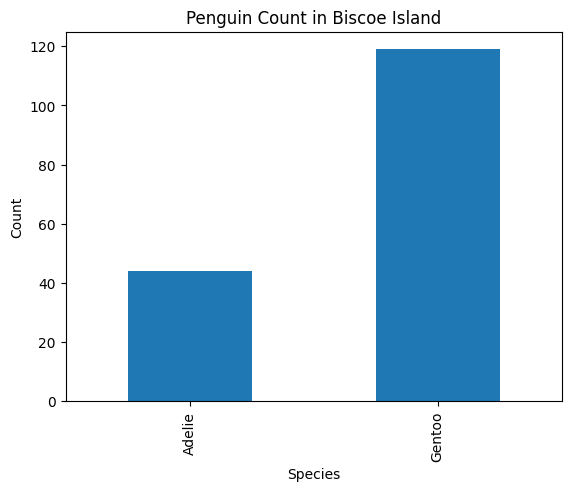

In [69]:
# Filter penguins in Biscoe island
biscoe_penguins = df[df["island"] == "Biscoe"]

# Group by species, count rows
penguin_count = biscoe_penguins.groupby("species").size()

penguin_count.plot(kind="bar")

plt.title("Penguin Count in Biscoe Island")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()


Column chart — Penguin count on Biscoe (by species)

On Biscoe Island, Gentoo penguins predominate; no Chinstrap individuals are recorded.


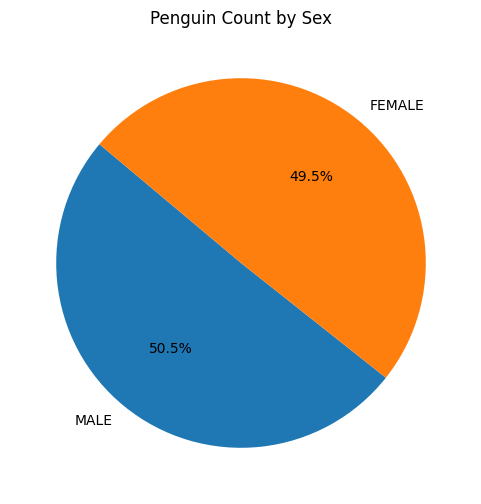

In [59]:
sex_count = df["sex"].value_counts()

plt.figure(figsize=(6,6))


#plot the pie chart

plt.pie(sex_count, labels=sex_count.index, autopct='%1.1f%%', startangle=140)
plt.title("Penguin Count by Sex")

plt.show()

Pie chart — Sex distribution

The dataset shows a near-balanced split between females and males.
This suggests no strong sex bias in the observations.

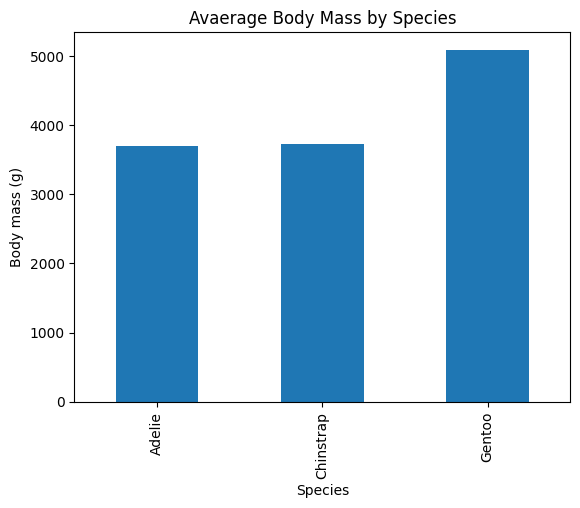

In [68]:
penguin_size =df.groupby("species")["body_mass_g"].mean()
penguin_size.plot(kind="bar")

plt.title("Avaerage Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")

plt.show()

Column chart — Average body mass by species

Gentoo have the highest average body mass, Adélie the lowest, Chinstrap sit between the two.
This order is consistent with species’ known size differences.

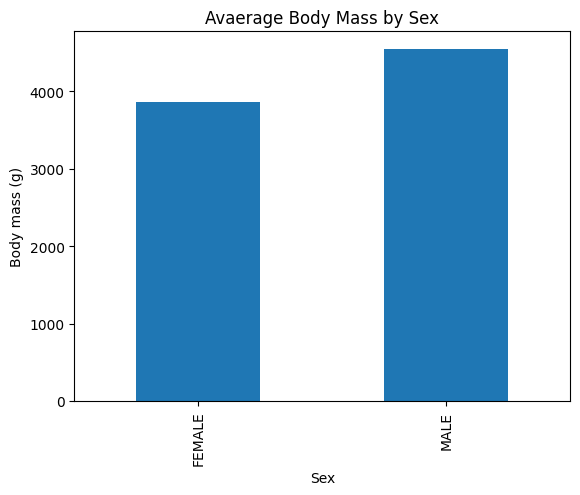

In [67]:
mask = df["sex"].str.upper().isin(["MALE", "FEMALE"])
sex_size=df.groupby("sex")["body_mass_g"].mean()
sex_size.plot(kind="bar")

plt.title("Avaerage Body Mass by Sex")
plt.xlabel("Sex")
plt.ylabel("Body mass (g)")

plt.show()

Column chart — Average body mass by sex

Males are heavier than females on average, which is typical sexual size dimorphism in penguins.

<Figure size 800x500 with 0 Axes>

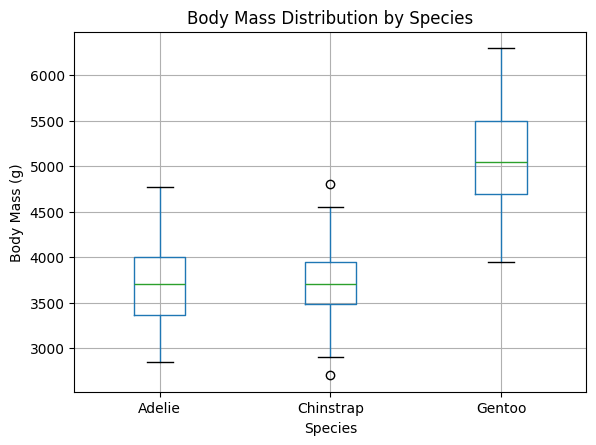

In [65]:
plt.figure(figsize=(8,5))
df.boxplot(column="body_mass_g", by="species")
plt.title("Body Mass Distribution by Species")
plt.suptitle("")  # remove the automatic subtitle
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

Box plot — Body mass distribution by species

Gentoo show the highest medians and generally heavier bodies.
Adélie have the lowest medians.
Chinstrap are intermediate.

<Figure size 800x500 with 0 Axes>

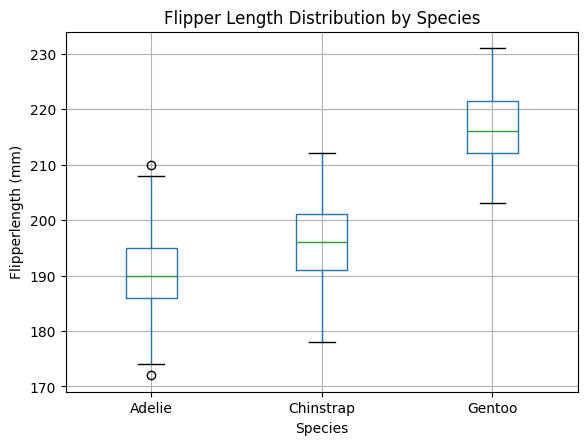

In [66]:
plt.figure(figsize=(8,5))
df.boxplot(column="flipper_length_mm", by="species")
plt.title("Flipper Length Distribution by Species")
plt.suptitle("")  # remove the automatic subtitle
plt.xlabel("Species")
plt.ylabel("Flipperlength (mm)")
plt.show()

Box plot — Flipper length distribution by species

Gentoo have the longest flippers (highest medians).
Adélie are shorter on average; Chinstrap are in between.

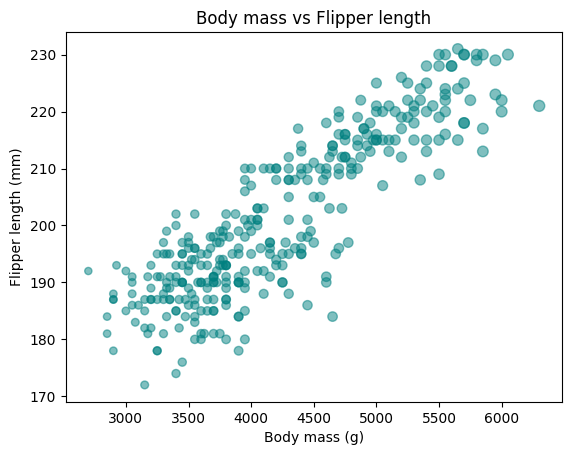

In [53]:
plt.scatter(df["body_mass_g"], df["flipper_length_mm"], s=df["body_mass_g"]*0.01, alpha=0.5, c='teal')
plt.xlabel("Body mass (g)")
plt.ylabel("Flipper length (mm)")
plt.title("Body mass vs Flipper length")
plt.show()

Scatter/Bubble — Body mass vs flipper length

There is a strong positive relationship: heavier penguins tend to have longer flippers.

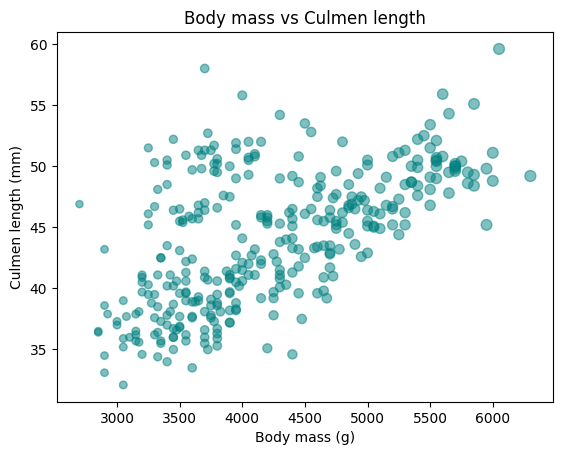

In [52]:

plt.scatter(df["body_mass_g"], df["culmen_length_mm"], s=df["body_mass_g"]*0.01, alpha=0.5, c='teal')
plt.xlabel("Body mass (g)")
plt.ylabel("Culmen length (mm)")
plt.title("Body mass vs Culmen length")
plt.show()

Scatter — Body mass vs culmen length/depth

Relationship is positive (larger body mass associates with longer/deeper culmen).

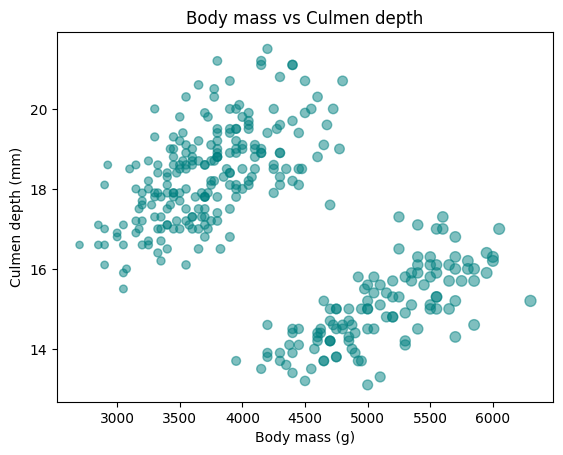

In [51]:
plt.scatter(df["body_mass_g"], df["culmen_depth_mm"], s=df["body_mass_g"]*0.01, alpha=0.5, c='teal')
plt.xlabel("Body mass (g)")
plt.ylabel("Culmen depth (mm)")
plt.title("Body mass vs Culmen depth")
plt.show()

Scatter — Body mass vs culmen depth

Across species there is an apparent negative association: heavier penguins (mainly Gentoo) tend to have shallower culmens, while lighter penguins (Adélie/Chinstrap) have deeper culmens.